In [1]:
import numpy as np
from donations.data_drift_detector import DataDriftDetector

In [2]:
ddd = DataDriftDetector(
    test_method='combined', reference_window_size=50, rolling_window_size=50
)

In [ ]:
# Generate synthetic data to showcase working of the detector

n_samples = 100
reference_data = np.random.normal(100, 15, n_samples)
same_data = np.random.normal(100, 15, n_samples)
diff_data = np.random.normal(120, 20, n_samples)

ddd.set_reference_data(reference_data)

In [ ]:
# Should detect no drift
ddd.detect_drift_single_window(same_data)

{'test': 'combined',
 'ks_statistic': np.float64(0.14),
 'ks_p_value': np.float64(0.5184691456556819),
 'mw_statistic': np.float64(2775.0),
 'mw_p_value': np.float64(0.2737979095280356),
 'drift_detected': np.False_,
 'min_p_value': np.float64(0.2737979095280356),
 'window_start_idx': None,
 'reference_size': 50,
 'test_size': 100,
 'test_method': 'combined'}

In [ ]:
# Should detect drift
ddd.detect_drift_single_window(diff_data)

{'test': 'combined',
 'ks_statistic': np.float64(0.43),
 'ks_p_value': np.float64(5.78922711377136e-06),
 'mw_statistic': np.float64(1237.0),
 'mw_p_value': np.float64(4.822326483071915e-07),
 'drift_detected': np.True_,
 'min_p_value': np.float64(4.822326483071915e-07),
 'window_start_idx': None,
 'reference_size': 50,
 'test_size': 100,
 'test_method': 'combined'}

In [54]:
import pickle

with open("tmp/df_all.pkl", "rb") as file:
    df_all = pickle.load(file)

In [55]:
my_drift  = DataDriftDetector(
    reference_window_size=90, rolling_window_size=90, test_method='combined'
)

my_drift.set_reference_data(df_all, column='all')

In [56]:
my_drift.detect_drift_single_window(df_all['all'][90:180])

{'test': 'combined',
 'ks_statistic': np.float64(0.12222222222222222),
 'ks_p_value': np.float64(0.5145202385052693),
 'mw_statistic': np.float64(4475.0),
 'mw_p_value': np.float64(0.22456429594368865),
 'drift_detected': np.False_,
 'min_p_value': np.float64(0.22456429594368865),
 'window_start_idx': None,
 'reference_size': 90,
 'test_size': 90,
 'test_method': 'combined'}

In [57]:
my_drift.detect_drift_single_window(df_all['all'][500:530])

{'test': 'combined',
 'ks_statistic': np.float64(0.2222222222222222),
 'ks_p_value': np.float64(0.2018834787858234),
 'mw_statistic': np.float64(1202.5),
 'mw_p_value': np.float64(0.37297296335877084),
 'drift_detected': np.False_,
 'min_p_value': np.float64(0.2018834787858234),
 'window_start_idx': None,
 'reference_size': 90,
 'test_size': 30,
 'test_method': 'combined'}

In [58]:
my_drift.detect_drift_single_window(df_all['all'][-90:])

{'test': 'combined',
 'ks_statistic': np.float64(0.7444444444444445),
 'ks_p_value': np.float64(1.4558783925167838e-24),
 'mw_statistic': np.float64(669.0),
 'mw_p_value': np.float64(3.98614367651905e-22),
 'drift_detected': np.True_,
 'min_p_value': np.float64(1.4558783925167838e-24),
 'window_start_idx': None,
 'reference_size': 90,
 'test_size': 90,
 'test_method': 'combined'}

Drift detected at positions 90 to 180. Resetting reference data.
Drift detected at positions 160 to 250. Resetting reference data.
Drift detected at positions 220 to 310. Resetting reference data.
Drift detected at positions 310 to 400. Resetting reference data.
Drift detected at positions 370 to 460. Resetting reference data.
Drift detected at positions 410 to 500. Resetting reference data.
Drift detected at positions 510 to 600. Resetting reference data.
Drift detected at positions 570 to 660. Resetting reference data.
Drift detected at positions 670 to 760. Resetting reference data.
Drift detected at positions 740 to 830. Resetting reference data.
Drift detected at positions 830 to 920. Resetting reference data.
Drift detected at positions 880 to 970. Resetting reference data.
Drift detected at positions 940 to 1030. Resetting reference data.
Drift detected at positions 1090 to 1180. Resetting reference data.
Drift detected at positions 1320 to 1410. Resetting reference data.
Drift 

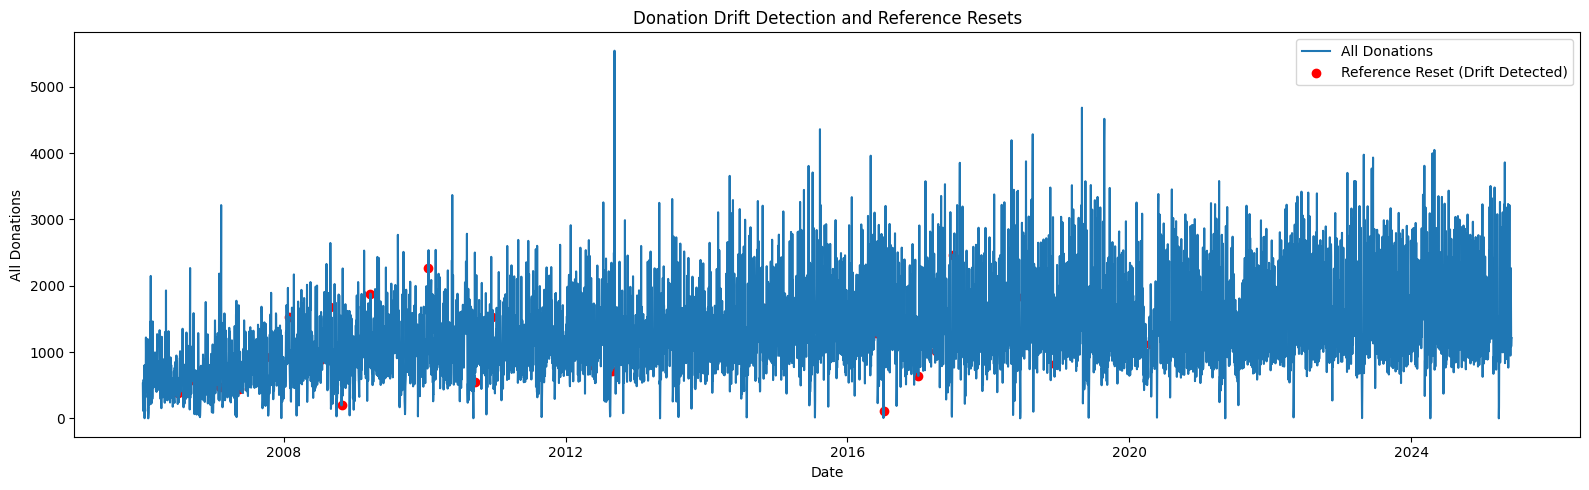

In [61]:
import matplotlib.pyplot as plt

# Prepare data for plotting
all_values = df_all['all'].to_numpy()
dates = df_all['date'].to_numpy()
reset_points = []

reset_count = 0
chunk_size = 10
window_size = 90

# We'll collect the reset indices for visualization
for i in range(window_size, len(df_all) - window_size, chunk_size):
    test_data = df_all['all'][i:i+window_size]
    drift_detected = my_drift.detect_drift_single_window(test_data)
    if drift_detected['drift_detected']:
        print(f"Drift detected at positions {i} to {i+90}. Resetting reference data.")
        reset_points.append(i + window_size)  # Mark the end of the window
        my_drift.set_reference_data(test_data.to_numpy())
        reset_count += 1

# Plot
plt.figure(figsize=(16, 5))
plt.plot(dates, all_values, label='All Donations')
plt.scatter([dates[idx] for idx in reset_points], [all_values[idx] for idx in reset_points],
            color='red', marker='o', label='Reference Reset (Drift Detected)')
plt.title('Donation Drift Detection and Reference Resets')
plt.xlabel('Date')
plt.ylabel('All Donations')
plt.legend()
plt.tight_layout()
plt.show()